In [26]:
import torch
import torchvision.models as models

# Download ResNet18 pre-trained on ImageNet
resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Save the model locally if needed
torch.save(resnet18.state_dict(), 'resnet18_pretrained.pth')

print("ResNet18 downloaded successfully!")

ResNet18 downloaded successfully!


In [27]:
# Load an image for testing
from PIL import Image
from torchvision import transforms

# Define preprocessing
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Load a sample image (replace with your own)
img = Image.open('Abyssinian_22.jpg')
input_tensor = preprocess(img)
input_batch = input_tensor.unsqueeze(0)  # Add batch dimension

# Move to GPU if available
if torch.cuda.is_available():
    input_batch = input_batch.to('cuda')
    resnet18.to('cuda')

# Set model to evaluation mode
resnet18.eval()

# Get prediction
with torch.no_grad():
    output = resnet18(input_batch)

# Print top-5 predictions
probabilities = torch.nn.functional.softmax(output[0], dim=0)
top5_prob, top5_catid = torch.topk(probabilities, 5)
print("Top 5 predictions:", top5_prob, top5_catid)

Top 5 predictions: tensor([0.3940, 0.2500, 0.1169, 0.1037, 0.0300], device='cuda:0') tensor([285, 281, 287, 282, 284], device='cuda:0')


In [28]:
import torch
import torchvision.models as models
from PIL import Image
from torchvision import transforms

# Download ResNet18 pre-trained on ImageNet
weights = models.ResNet18_Weights.IMAGENET1K_V1
resnet18 = models.resnet18(weights=weights)
resnet18.eval()

# Get the class labels from the weights
categories = weights.meta["categories"]

# Define preprocessing using the weights' recommended transforms
preprocess = weights.transforms()

# Load a sample image (replace with your own)
img = Image.open('Abyssinian_22.jpg')
input_tensor = preprocess(img)
input_batch = input_tensor.unsqueeze(0)  # Add batch dimension

# Move to GPU if available
if torch.cuda.is_available():
    input_batch = input_batch.to('cuda')
    resnet18.to('cuda')

# Get prediction
with torch.no_grad():
    output = resnet18(input_batch)

# Process the output
probabilities = torch.nn.functional.softmax(output[0], dim=0)
top5_prob, top5_catid = torch.topk(probabilities, 5)

# Print top-5 predictions with class names
print("Top 5 predictions:")
for i in range(5):
    print(f"{categories[top5_catid[i]]}: {top5_prob[i].item()*100:.2f}%")

Top 5 predictions:
Egyptian cat: 39.40%
tabby: 25.00%
lynx: 11.69%
tiger cat: 10.37%
Siamese cat: 3.00%


Model loaded successfully!
Using torchvision's built-in class labels.


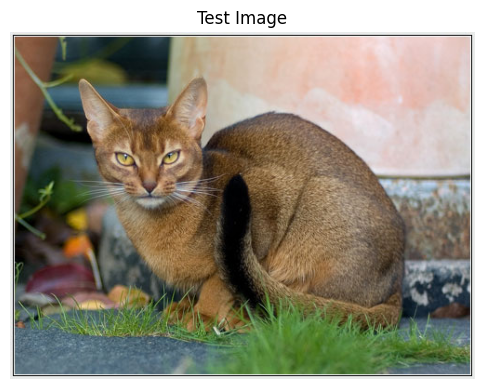

Using device: cuda

Top 5 predictions:
Egyptian cat: 39.40%
tabby: 25.00%
lynx: 11.69%
tiger cat: 10.37%
Siamese cat: 3.00%


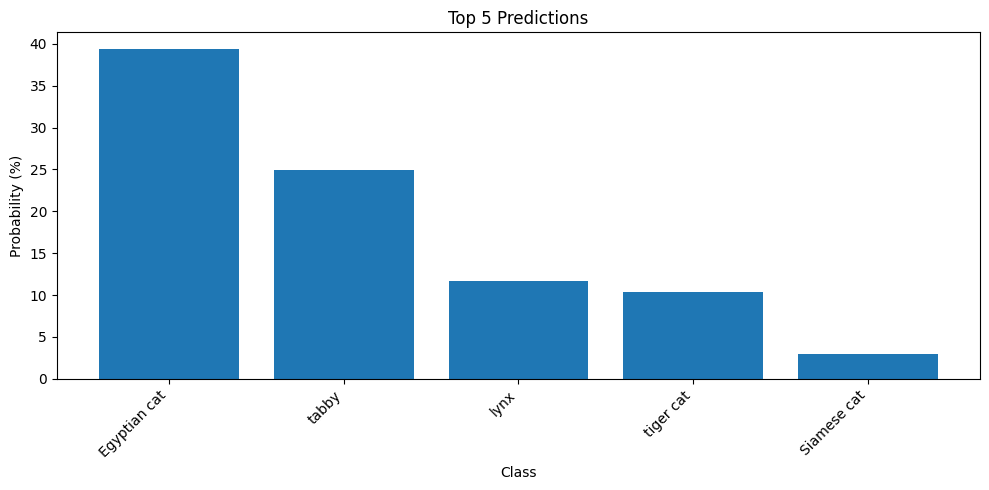


Verification complete! The model is working correctly.


In [29]:
import torch
import torchvision.models as models
from PIL import Image
from torchvision import transforms
import os
import matplotlib.pyplot as plt

# Path to your saved model
saved_model_path = 'resnet18_pretrained.pth'

# Check if the model file exists
if not os.path.exists(saved_model_path):
    print(f"Model file not found at {saved_model_path}")
    print("Please run the save model script first.")
    exit()

# 1. Load the model architecture
model = models.resnet18()  # Create empty model with architecture

# 2. Load the saved weights
model.load_state_dict(torch.load(saved_model_path))
model.eval()  # Set to evaluation mode

print("Model loaded successfully!")

# 3. Get ImageNet classes
try:
    # Method 1: Use torchvision's built-in class labels
    weights = models.ResNet18_Weights.IMAGENET1K_V1
    categories = weights.meta["categories"]
    preprocess = weights.transforms()
    print("Using torchvision's built-in class labels.")
except:
    # Method 2: Download class labels if Method 1 fails
    import urllib.request
    url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
    with urllib.request.urlopen(url) as response:
        categories = [line.decode('utf-8').strip() for line in response.readlines()]
    
    # Define preprocessing manually
    preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    print("Downloaded class labels from GitHub.")

# 4. Load and preprocess a test image
# Replace with path to your test image
test_image_path = 'Abyssinian_22.jpg'

if not os.path.exists(test_image_path):
    print(f"Test image not found at {test_image_path}")
    print("Please provide a valid test image path.")
    exit()

# Load and display the image
img = Image.open(test_image_path)
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title("Test Image")
plt.axis('off')
plt.show()

# Preprocess the image
input_tensor = preprocess(img)
input_batch = input_tensor.unsqueeze(0)  # Add batch dimension

# 5. Move to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_batch = input_batch.to(device)
model = model.to(device)
print(f"Using device: {device}")

# 6. Run inference
with torch.no_grad():
    outputs = model(input_batch)

# 7. Process and display results
probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
top5_prob, top5_catid = torch.topk(probabilities, 5)

print("\nTop 5 predictions:")
for i in range(5):
    print(f"{categories[top5_catid[i]]}: {top5_prob[i].item()*100:.2f}%")

# 8. Create a bar chart of the results
plt.figure(figsize=(10, 5))
plt.bar(
    [categories[idx] for idx in top5_catid],
    [prob.item() * 100 for prob in top5_prob]
)
plt.xlabel('Class')
plt.ylabel('Probability (%)')
plt.title('Top 5 Predictions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nVerification complete! The model is working correctly.")

In [12]:
import os
import torch

# Set device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


In [ ]:
# test parse_list_file
def parse_list_file(base_dir):
    list_path = os.path.join(base_dir, "annotations", "list.txt")
    
    images = []
    labels_multiclass = []  #ID: 1:37 Class ids
    label_species = []  #SPECIES: 1:Cat 2:Dog
    label_breeds = [] #BREED ID: 1-25:Cat 1:12:Dog
    
    with open(list_path, 'r') as f:
        # Skip the header lines
        list_lines = [line.strip() for line in f if not line.startswith('#')]
            
    for line in list_lines:
        if not line: continue
        
        parts = line.strip().split()
        if len(parts) >= 4:  # Ensure we have all needed fields
            image_name = parts[0]
            class_id = int(parts[1]) 
            species = int(parts[2])  # 1: Cat, 2: Dog
            breeds = int(parts[3]) 
            
            images.append(image_name)
            labels_multiclass.append(class_id)
            label_species.append(species)
            label_breeds.append(breeds)
    
    return images, labels_multiclass, label_species, label_breeds

images, labels_multiclass, label_species, label_breeds = parse_list_file('../The_Oxford-IIIT_Pet_Dataset')
print(len(labels_multiclass))
images

7349


['Abyssinian_100',
 'Abyssinian_101',
 'Abyssinian_102',
 'Abyssinian_103',
 'Abyssinian_104',
 'Abyssinian_105',
 'Abyssinian_106',
 'Abyssinian_107',
 'Abyssinian_108',
 'Abyssinian_109',
 'Abyssinian_10',
 'Abyssinian_110',
 'Abyssinian_111',
 'Abyssinian_112',
 'Abyssinian_113',
 'Abyssinian_114',
 'Abyssinian_115',
 'Abyssinian_116',
 'Abyssinian_117',
 'Abyssinian_118',
 'Abyssinian_119',
 'Abyssinian_11',
 'Abyssinian_120',
 'Abyssinian_121',
 'Abyssinian_122',
 'Abyssinian_123',
 'Abyssinian_124',
 'Abyssinian_125',
 'Abyssinian_126',
 'Abyssinian_127',
 'Abyssinian_128',
 'Abyssinian_129',
 'Abyssinian_12',
 'Abyssinian_130',
 'Abyssinian_131',
 'Abyssinian_132',
 'Abyssinian_133',
 'Abyssinian_134',
 'Abyssinian_135',
 'Abyssinian_136',
 'Abyssinian_137',
 'Abyssinian_138',
 'Abyssinian_139',
 'Abyssinian_13',
 'Abyssinian_140',
 'Abyssinian_141',
 'Abyssinian_142',
 'Abyssinian_143',
 'Abyssinian_144',
 'Abyssinian_145',
 'american_bulldog_100',
 'american_bulldog_101',
 'am